In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import shutil
import random
from PIL import Image
import zipfile

# Define the paths
zip_file_path = '/content/drive/MyDrive/Pomegranate Diseases Dataset.zip'  # Path to your zip file
input_dir = '/content/drive/MyDrive/pomegranate_unzipped'  # Path to unzip the dataset
output_dir = '/content/drive/MyDrive/pomegranate_toprocess'  # Path to save the processed images

# Unzip the dataset
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(input_dir)

# Define the target number of images per class
target_count = 1300

# Get the number of images per class
class_counts = {
    'Healthy': 1450,
    'Cercospora': 631,
    'Bacterial_Blight': 966,
    'Anthracnose': 1166,
    'Alternaria': 886
}
extra_path='/content/drive/MyDrive/pomegranate_unzipped/Pomegranate Diseases Dataset'
# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Copy the 'healthy' class without any changes
healthy_dir = os.path.join(extra_path, 'Healthy')
healthy_output_dir = os.path.join(output_dir, 'Healthy')
os.makedirs(healthy_output_dir, exist_ok=True)
for filename in os.listdir(healthy_dir):
    src_path = os.path.join(healthy_dir, filename)
    dst_path = os.path.join(healthy_output_dir, filename)
    shutil.copy(src_path, dst_path)

# Duplicate images for classes with fewer than the target count
for class_name, count in class_counts.items():
    if class_name != 'Healthy':
        class_dir = os.path.join(extra_path, class_name)
        output_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(output_class_dir, exist_ok=True)

        # Copy existing images
        for i, filename in enumerate(os.listdir(class_dir)):
            src_path = os.path.join(class_dir, filename)
            dst_path = os.path.join(output_class_dir, filename)

            # Check if the image is corrupt
            try:
                Image.open(src_path)
                shutil.copy(src_path, dst_path)
            except:
                print(f"Skipping corrupt image: {filename}")
                continue

        # Duplicate images if the class has fewer than the target count
        if count < target_count:
            for i in range(count, target_count):
                src_index = random.randint(0, count - 1)
                src_filename = os.listdir(class_dir)[src_index]
                src_path = os.path.join(class_dir, src_filename)
                dst_filename = f"{class_name}_{i}.jpg"
                dst_path = os.path.join(output_class_dir, dst_filename)
                shutil.copy(src_path, dst_path)

# Resize the images for the DenseNet model
for class_name in os.listdir(output_dir):
    class_dir = os.path.join(output_dir, class_name)
    for filename in os.listdir(class_dir):
        img_path = os.path.join(class_dir, filename)
        img = Image.open(img_path)
        img = img.resize((224, 224))
        img.save(img_path)

print("Dataset preprocessing complete. The balanced and resized dataset is available in the output directory.")


Dataset preprocessing complete. The balanced and resized dataset is available in the output directory.


In [ ]:
# Define the path to your directory
directory_path = '/content/drive/MyDrive/pomegranate_toprocess/Alternaria'  # Update this to your target directory

# Initialize a counter
image_count = 0

# List all files in the directory and count images
for filename in os.listdir(directory_path):
    if filename.endswith(('.png', '.jpg', '.jpeg', '.gif')):  # Add other image formats if needed
        image_count += 1

print(f"Number of images in the directory: {image_count}")


Number of images in the directory: 1300


In [ ]:

from PIL import Image

# Path to your folder
folder_path = '/content/drive/MyDrive/pomegranate_toprocess/Alternaria'

# Initialize list to store corrupt images
corrupt_images = []

# Iterate through the files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(('png', 'jpg', 'jpeg', 'bmp', 'gif')):  # Add more extensions if needed
        file_path = os.path.join(folder_path, filename)
        try:
            # Try opening the image
            with Image.open(file_path) as img:
                # Check if the image can be fully loaded
                img.verify()
        except (IOError, SyntaxError) as e:
            # If an error occurs, append the corrupt image to the list
            print(f"Corrupt image detected: {filename}")
            corrupt_images.append(filename)

# Output the list of corrupt images, if any
if corrupt_images:
    print("Corrupt images found:", corrupt_images)
else:
    print("No corrupt images found.")


No corrupt images found.


In [ ]:
import shutil
import random

# Set the seed for reproducibility
random.seed(42)

# Define the dataset paths
input_dir = '/content/drive/MyDrive/pomegranate_toprocess'  # Original dataset
output_dir = '/content/drive/MyDrive/pomegranate_split'  # New directory for split data

# Create output directories for train, val, and test
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

# Define the classes
classes = ['Alternaria', 'Anthracnose', 'Bacterial_Blight', 'Cercospora', 'Healthy']

# Create class subdirectories in train, val, and test directories
for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

# Split dataset into train, val, test (70% train, 15% val, 15% test)
split_ratio = [0.7, 0.15, 0.15]

for cls in classes:
    class_dir = os.path.join(input_dir, cls)
    images = os.listdir(class_dir)

    # Shuffle the images to randomize selection
    random.shuffle(images)

    # Calculate split sizes
    total_images = len(images)
    train_size = int(total_images * split_ratio[0])
    val_size = int(total_images * split_ratio[1])

    # Split the data
    train_images = images[:train_size]
    val_images = images[train_size:train_size + val_size]
    test_images = images[train_size + val_size:]

    # Move images to their respective directories
    for img in train_images:
        src = os.path.join(class_dir, img)
        dest = os.path.join(train_dir, cls, img)
        shutil.copyfile(src, dest)

    for img in val_images:
        src = os.path.join(class_dir, img)
        dest = os.path.join(val_dir, cls, img)
        shutil.copyfile(src, dest)

    for img in test_images:
        src = os.path.join(class_dir, img)
        dest = os.path.join(test_dir, cls, img)
        shutil.copyfile(src, dest)

print("Dataset split completed successfully.")

# Print the number of images in each split for each class
for split in ['train', 'val', 'test']:
    print(f"\n{split.capitalize()} set:")
    for cls in classes:
        num_images = len(os.listdir(os.path.join(output_dir, split, cls)))
        print(f"  {cls}: {num_images} images")

Dataset split completed successfully.

Train set:
  Alternaria: 909 images
  Anthracnose: 909 images
  Bacterial_Blight: 909 images
  Cercospora: 909 images
  Healthy: 1014 images

Val set:
  Alternaria: 195 images
  Anthracnose: 195 images
  Bacterial_Blight: 195 images
  Cercospora: 195 images
  Healthy: 217 images

Test set:
  Alternaria: 196 images
  Anthracnose: 196 images
  Bacterial_Blight: 196 images
  Cercospora: 196 images
  Healthy: 219 images


In [ ]:
import os
import numpy as np
import tensorflow as tf
from keras.utils import image_dataset_from_directory

def create_data_generators(input_dir, batch_size=32):
    # Set the input directory for the preprocessed dataset
    train_dir = os.path.join(input_dir, 'train')
    val_dir = os.path.join(input_dir, 'val')
    test_dir = os.path.join(input_dir, 'test')

    # Create the data generators using image_dataset_from_directory
    train_generator = image_dataset_from_directory(
        train_dir,
        image_size=(224, 224),
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=True
    )

    val_generator = image_dataset_from_directory(
        val_dir,
        image_size=(224, 224),
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=False
    )

    test_generator = image_dataset_from_directory(
        test_dir,
        image_size=(224, 224),
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=False
    )

    # Calculate steps per epoch
    steps_per_epoch = len(train_generator)
    validation_steps = len(val_generator)

    print("Number of training samples:", len(train_generator))
    print("Number of validation samples:", len(val_generator))
    print("Number of test samples:", len(test_generator))
    print("Number of classes:", train_generator.cardinality())

    return train_generator, val_generator, test_generator

if __name__ == "__main__":
    input_dir = '/content/drive/MyDrive/pomegranate_split'
    create_data_generators(input_dir)
    print("Data generators created successfully.")


Found 4650 files belonging to 5 classes.
Found 997 files belonging to 5 classes.
Found 1003 files belonging to 5 classes.
Number of training samples: 146
Number of validation samples: 32
Number of test samples: 32
Number of classes: tf.Tensor(146, shape=(), dtype=int64)
Data generators created successfully.


In [ ]:


import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def build_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    frozen_layers = sum([1 for layer in model.layers if not layer.trainable])
    unfrozen_layers = sum([1 for layer in model.layers if layer.trainable])
    print(f"Number of frozen layers: {frozen_layers}")
    print(f"Number of unfrozen layers: {unfrozen_layers}")

    return model

if __name__ == "__main__":
    model = build_model()
    model.summary()

Number of frozen layers: 427
Number of unfrozen layers: 3


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_10         │ (None, 230, 230, 3)    │              0 │ input_layer_5[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d_10[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_11         │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_11[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 7,301,189 (27.85 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, CSVLogger, EarlyStopping
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight




def train_model(model, train_generator, val_generator, epochs=50, save_path='/content/drive/MyDrive/'):
    # Set up callbacks
    class_weights = compute_class_weight('balanced',
                                     classes=np.unique(train_generator.classes),
                                     y=train_generator.classes)
    class_weights = {i: weight for i, weight in enumerate(class_weights)}



    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

    checkpoint = ModelCheckpoint(
        filepath=os.path.join(save_path, 'best_model.keras'),
        monitor='val_accuracy',  # Monitoring validation accuracy
        mode='max',              # Saving model with the maximum validation accuracy
        save_best_only=True,      # Only saving the best model
        verbose=1
    )

    csv_logger = CSVLogger(os.path.join(save_path, 'training_log.csv'))
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size)
    validation_steps = math.ceil(val_generator.samples / val_generator.batch_size)

    # Confirm that generators are yielding data
    x_train, y_train = next(train_generator)
    x_val, y_val = next(val_generator)

    print("Training data shape:", x_train.shape)
    print("Validation data shape:", x_val.shape)

    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        validation_data=val_generator,
        validation_batch_size=batch_size,  # Use validation_batch_size here
        callbacks=[reduce_lr, checkpoint, csv_logger, early_stopping],
        class_weight=class_weights
    )

    return history

def plot_training_history(history, save_path):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, 'training_history.png'))
    plt.show()

# Train the model
save_path = '/content/drive/MyDrive/'
history = train_model(model, train_generator, val_generator, epochs=50, save_path=save_path)

# Plot training history
plot_training_history(history, save_path)

# Find the best validation accuracy and its corresponding epoch
if 'val_accuracy' in history.history:
    best_val_accuracy = max(history.history['val_accuracy'])
    best_epoch = history.history['val_accuracy'].index(best_val_accuracy) + 1
    print(f'Best Validation Accuracy: {best_val_accuracy:.4f} at Epoch: {best_epoch}')

# Save the final model
model.save(os.path.join(save_path, 'final_model.h5'))
print("Training completed and model saved successfully.")


Training data shape: (32, 224, 224, 3)
Validation data shape: (32, 224, 224, 3)
Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9837 - loss: 0.0495
Epoch 1: val_accuracy improved from -inf to 0.98897, saving model to /content/drive/MyDrive/best_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 1178s 8s/step - accuracy: 0.9837 - loss: 0.0496 - val_accuracy: 0.9890 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 2/50


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 2: val_accuracy did not improve from 0.98897
146/146 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9890 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 3/50
122/146 ━━━━━━━━━━━━━━━━━━━━ 2:34 6s/step - accuracy: 0.9853 - loss: 0.0441

KeyboardInterrupt: 

Class distribution:
Alternaria: 196
Anthracnose: 196
Bacterial_Blight: 196
Cercospora: 196
Healthy: 219


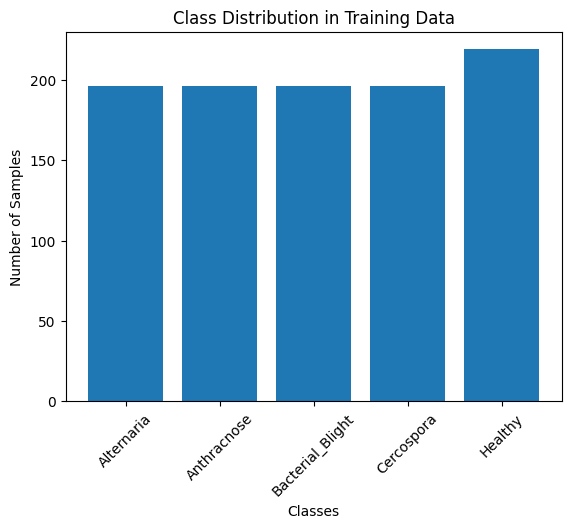

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Set the path to your training data
train_data_dir = '/content/drive/MyDrive/pomegranate_split/test'

# Initialize a dictionary to count classes
class_counts = {}

# Loop through the classes in the directory
for class_name in os.listdir(train_data_dir):
    class_dir = os.path.join(train_data_dir, class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))

# Print the class counts
print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

# Visualize the class distribution
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.bar(classes, counts)
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Training Data')
plt.xticks(rotation=45)
plt.show()
